In [1]:
from datetime import datetime, timedelta
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [68]:
heatwave_date = datetime.fromisoformat("2025-07-27")

In [4]:
block_groups = con.sql("SELECT * FROM block_groups").pl()
block_groups

GEOID,OGC_FID,STATEFP,COUNTYFP,ALAND,MSA_CODE,MSA_NAME,MEDIAN_HH_INCOME,MEDIAN_HH_INCOME_MOE,GEOM,CENTROID
str,i64,str,str,i64,str,str,f64,f64,binary,binary
"""011030051072""",7,"""01""","""103""",29113512,"""C1946""","""Decatur, AL MSA""",76542.0,2262.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x8f\x06\x00\x00\xa9\xf9*\xf9\xd8\xc6U\xc0<\xf8\x89\x03\xe8?A@\xc1;\xf9\xf4\xd8\xc6U\xc0""4\x82\x8d\xeb?A@8\x86\x00\xe0\xd8\xc6U\xc0\x81v\x87\x14\x03@A""…","b""\x01\x01\x00\x00\x00\xe1\xa2\x9dr\x1f\xc5U\xc0\xfa\xb0\x02InDA@"""
"""011030051071""",8,"""01""","""103""",14227230,"""C1946""","""Decatur, AL MSA""",105859.0,49893.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xbb\x02\x00\x00L\xa8\xe0\xf0\x82\xc3U\xc0\xb5pY\x85\xcdDA@\xb7^\xd3\x83\x82\xc3U\xc0\x12\x11\xfeE\xd0DA@\x1d>\xe9D\x82\xc3U\xc0|_\\xaa\xd2DA""…","b""\x01\x01\x00\x00\x00/\x91I\xb9:\xc2U\xc0fhdc\xcbBA@"""
"""010890110132""",9,"""01""","""089""",2279535,"""C2662""","""Huntsville, AL MSA""",155885.0,17980.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xae\x00\x00\x00C\x8f\x18=\xb7\xaeU\xc0E\xd5\xaft>\A@\x0d\x17\xb9\xa7\xab\xaeU\xc0\x10\x94\xdb\xf6=\A@\xd5\xb1J\xe9\x99\xaeU\xc0\xab\xcej\x81=\A""…","b""\x01\x01\x00\x00\x005\xbd\x01\x14\xcf\xadU\xc0~3\xfe\x8d\x90[A@"""
"""010950309043""",10,"""01""","""095""",21348377,"""C1070""","""Albertville, AL MicroSA""",115609.0,19996.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xa7\x01\x00\x00\x89\xd4\xb4\x8bi\x95U\xc0$%=\x0c\xad\x20A@\x19\xe3\xc3\xece\x95U\xc0\xb6j\xd7\x84\xb4\x20A@m:\x02\xb8Y\x95U\xc0v4\x0e\xf5\xbb\x20A""…","b""\x01\x01\x00\x00\x00q\xb3N\xcaZ\x92U\xc0WO\xbc\x04\x83\x1fA@"""
"""010890110212""",11,"""01""","""089""",4945980,"""C2662""","""Huntsville, AL MSA""",142571.0,65810.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xa7\x00\x00\x00\xc1\xe2p\xe6W\xb2U\xc0\x7f\xbe-X\xaaWA@h\xb1\x14\xc9W\xb2U\xc0\x85{e\xde\xaaWA@\xc1\xe2p\xe6W\xb2U\xc01\xed\x9b\xfb\xabWA""…","b""\x01\x01\x00\x00\x00c1U\xb9;\xb1U\xc0>\xa2\x19\x1e\xd0XA@"""
…,…,…,…,…,…,…,…,…,…,…
"""720559900000""",2337,"""72""","""055""",0,null,null,null,null,"b""\x01\x03\x00\x00\x00\x02\x00\x00\x00\x9a\x00\x00\x00E\xd9[\xca\xf9\xbfP\xc0\x834c\xd1t\xea1@\xb0\x91$\x08W\xbfP\xc03\xe1\x97\xfay\xef1@\x85Co\xf1\xf0\xbeP\xc0\x19\x8e\xe73\xa0\xf21""…","b""\x01\x01\x00\x00\x00\xbev__/\xbbP\xc0\x87\xf1x\xbb\xf9\xe81@"""
"""720019567001""",2376,"""72""","""001""",1031965,null,null,19708.0,6006.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xdc\x00\x00\x001\xeb\xc5PN\xaeP\xc0\x85\xb4\xc6\xa0\x13*2@\xd3\x16\xd7\xf8L\xaeP\xc0\xfb\xb0\xde\xa8\x15*2@3SZ\x7fK\xaeP\xc0\xe7\xa9\x0e\xb9\x19*2""…","b""\x01\x01\x00\x00\x00\x05]\xb9P\xd8\xadP\xc0\x1e$\xc1t\xa4*2@"""
"""720559610001""",2391,"""72""","""055""",27493938,null,null,18491.0,6349.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00W\x01\x00\x000e\xe0\x80\x96\xbdP\xc0D\x86U\xbc\x91\xfd1@\xffun\xda\x8c\xbdP\xc0\x16i\xe2\x1d\xe0\xfd1@=D\xa3;\x88\xbdP\xc0b\xf9\xf3m\xc1\xfe1""…","b""\x01\x01\x00\x00\x00\xeaW\xf26\x0b\xbcP\xc0,\x0a\x11\xe3\xb8\x002@"""


In [ ]:
visits = con.sql("""
    WITH data AS (
        SELECT 
            DATE_RANGE_START, HOME_GEOID,
            ST_Distance_Sphere(p.GEOM, bg.CENTROID) AS DIST,
            SUM(VISITOR_COUNTS) AS VISITOR_COUNTS
        FROM block_groups bg
        JOIN block_group_visits bgv ON bg.GEOID = bgv.HOME_GEOID
        JOIN pois p ON bgv.ID_STORE = p.ID_STORE
        GROUP BY 1, 2, 3
    )
    SELECT 
        DATE_RANGE_START, HOME_GEOID,
        SUM(DIST * VISITOR_COUNTS) / SUM(VISITOR_COUNTS) AS AVG_DIST,
        SUM(VISITOR_COUNTS) AS VISITOR_COUNTS
    FROM data
    GROUP BY 1, 2
""").pl()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [15]:
msa_visits = visits.join(block_groups, left_on="HOME_GEOID", right_on="GEOID").group_by("DATE_RANGE_START", "MSA_CODE", "MSA_NAME").agg(
    pl.col("VISITOR_COUNTS").sum(),
    ((pl.col("AVG_DIST") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("AVG_DIST")
)

In [44]:
n_largest_msa = set(msa_visits.group_by("MSA_CODE").agg(pl.col("VISITOR_COUNTS").sum()).top_k(4, by="VISITOR_COUNTS")["MSA_CODE"].to_list())
msa_visits = msa_visits.with_columns(
    pl.col("MSA_CODE").is_in(n_largest_msa).alias("IS_TOP_MSA")
).with_columns(
    pl.when(pl.col("IS_TOP_MSA"))
      .then(pl.col("MSA_NAME"))
      .otherwise(pl.lit("Other"))
      .alias("MSA_NAME")
)

In [69]:
closest_date = msa_visits.filter(pl.col("DATE_RANGE_START") <= heatwave_date)["DATE_RANGE_START"].max()
minus_three_weeks = heatwave_date - timedelta(days=3*7)
baseline_msa_visits = msa_visits.filter(
    (pl.col("DATE_RANGE_START") >= minus_three_weeks) & (pl.col("DATE_RANGE_START") <= heatwave_date))
baseline_agg = baseline_msa_visits.group_by("MSA_NAME").agg(
    pl.col("VISITOR_COUNTS").mean().alias("VISITOR_COUNTS_BASELINE"),
    pl.col("AVG_DIST").mean().alias("AVG_DIST_BASELINE"),
)

In [75]:
msa_visits = msa_visits.join(baseline_agg, on="MSA_NAME").with_columns(
    (pl.col("VISITOR_COUNTS") / pl.col("VISITOR_COUNTS_BASELINE")).alias("VISITOR_COUNTS_INDEX"),
    (pl.col("AVG_DIST") / pl.col("AVG_DIST_BASELINE")).alias("AVG_DIST_INDEX"),
)

<Axes: xlabel='AVG_DIST', ylabel='MSA_NAME'>

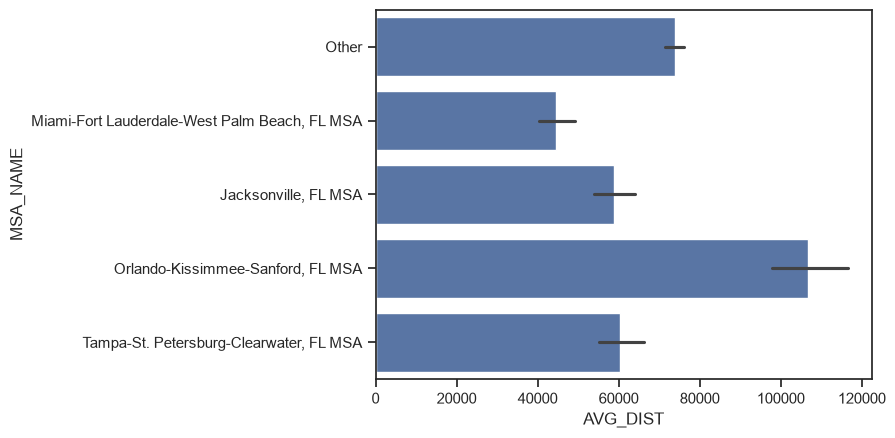

In [76]:
#sns.barplot(msa_visits, y="MSA_NAME", x="VISITOR_COUNTS")
sns.barplot(msa_visits, y="MSA_NAME", x="AVG_DIST")

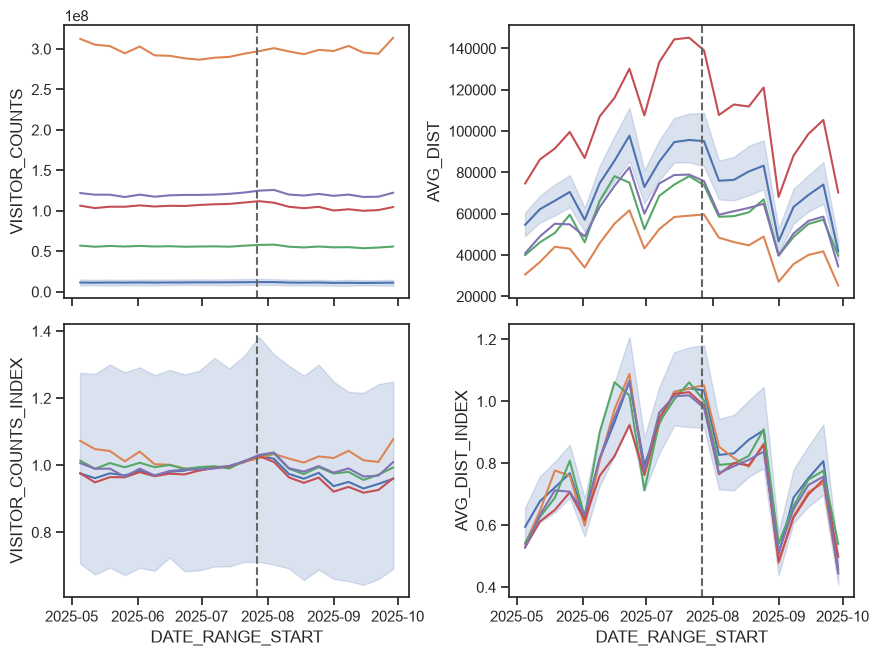

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(6.4*1.4, 4.8*1.4))
sns.lineplot(msa_visits, x="DATE_RANGE_START", y="VISITOR_COUNTS", hue="MSA_NAME", legend=False, ax=axes[0][0])
sns.lineplot(msa_visits, x="DATE_RANGE_START", y="AVG_DIST", hue="MSA_NAME", legend=False, ax=axes[0][1])

sns.lineplot(msa_visits, x="DATE_RANGE_START", y="VISITOR_COUNTS_INDEX", hue="MSA_NAME", legend=False, ax=axes[1][0])
sns.lineplot(msa_visits, x="DATE_RANGE_START", y="AVG_DIST_INDEX", hue="MSA_NAME", legend=False, ax=axes[1][1])

for ax in axes[0]:
    ax.set_xlabel("")
    ax.set_xticklabels("")

for ax in axes.flatten():
    ax.axvline(heatwave_date, color="#666", linestyle="--")
fig.tight_layout()

In [86]:
visits

DATE_RANGE_START,HOME_GEOID,AVG_DIST,VISITOR_COUNTS
datetime[μs],str,f64,"decimal[38,0]"
2025-05-05 00:00:00,"""120110201014""",4149.718309,147931
2025-05-05 00:00:00,"""120810003041""",13682.204746,69116
2025-05-05 00:00:00,"""120810007041""",4646.739369,43006
2025-05-05 00:00:00,"""120950139001""",81029.342904,122154
2025-05-05 00:00:00,"""120174515011""",24740.724828,79146
…,…,…,…
2025-09-29 00:00:00,"""120990070053""",2194.866348,72
2025-05-19 00:00:00,"""120939900000""",5867.465292,135
2025-09-08 00:00:00,"""120710503233""",1444.491296,106


In [85]:
msa_visits

DATE_RANGE_START,MSA_CODE,MSA_NAME,VISITOR_COUNTS,AVG_DIST,IS_TOP_MSA,VISITOR_COUNTS_BASELINE,AVG_DIST_BASELINE,VISITOR_COUNTS_INDEX,AVG_DIST_INDEX
datetime[μs],str,str,"decimal[38,0]",f64,bool,f64,f64,f64,f64
2025-06-09 00:00:00,"""C2946""","""Other""",23670128,64742.639823,false,1.1739e7,91872.466155,2.016357,0.704701
2025-08-11 00:00:00,"""C3726""","""Other""",1933028,44047.876116,false,1.1739e7,91872.466155,0.164666,0.479446
2025-05-26 00:00:00,"""C2858""","""Other""",5641545,117855.56591,false,1.1739e7,91872.466155,0.480579,1.282817
2025-05-05 00:00:00,"""C3726""","""Other""",2051621,39148.319667,false,1.1739e7,91872.466155,0.174769,0.426116
2025-09-22 00:00:00,"""C1598""","""Other""",27572437,64177.471031,false,1.1739e7,91872.466155,2.348778,0.69855
…,…,…,…,…,…,…,…,…,…
2025-07-28 00:00:00,"""C4270""","""Other""",3567918,58680.82388,false,1.1739e7,91872.466155,0.303936,0.63872
2025-09-01 00:00:00,"""C3786""","""Other""",20418366,46639.51751,false,1.1739e7,91872.466155,1.739353,0.507655
2025-09-29 00:00:00,"""C3610""","""Other""",11781217,36465.56307,false,1.1739e7,91872.466155,1.003592,0.396915
